# 02 — Bias Analysis
---

## Table of Contents

Under the **EU AI Act Requirement** the credit scoring systems must be tested for bias and discrimination. This notebook performs a bias analysis showing the bias patterns present in this dataset on Gender and Age.

This bias analysis follows a structured four-part framework. 

First, gender-based disparate impact is assessed through the Adverse Impact 
Ratio (AIR), Chi-Square Test, and logistic regression. The same methodology is then applied to age-based disparate impact. 

Subsequently, a proxy variable analysis is conducted to detect indirect discrimination through correlated financial variables. 

Finally, an intersectional analysis examines whether the combined effect of gender and age produces compounded disparities in loan approval outcomes.


#### Adverse Impact Ratio (AIR)

The Adverse Impact Ratio (AIR) is a standard metric used to detect disparate impact in decision-making processes.

Approval rates are first computed across groups. The group with the highest approval rate is designated as the **reference group**. The AIR is then defined as:

> AIR = Approval Rate (Protected Group) / Approval Rate (Reference Group)

Results are evaluated against the **4/5ths Rule**, established as the industry-standard threshold for adverse impact assessment:

| AIR Value | Interpretation |
|---|---|
| ≥ 0.80 | No adverse impact detected |
| < 0.80 | Potential discriminatory impact — further investigation warranted |

A statistically significant AIR below 0.80 may indicate systemic bias and constitute grounds for regulatory scrutiny under anti-discrimination frameworks.

In [202]:
# Now import
import pandas as pd
from pathlib import Path
import sys
import os
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import chi2_contingency, pearsonr, ttest_ind
import statsmodels.api as sm
import seaborn as sns

---
## 0. Load the data 
---

In [203]:
# Resolve root regardless of where the notebook is run from
cwd = Path.cwd()
root = cwd.parent if cwd.name == "notebooks" else cwd

# Build path to the cleaned file saved in the previous notebook
clean_path = root / "data" / "processed" / "applications_clean.csv"

# Load into dataframe
df = pd.read_csv(clean_path)

# Quick sanity check
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (500, 20)
Columns: ['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate', 'decision.approved_amount', 'ssn_is_duplicate']


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,ssn_is_duplicate
0,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230.0,102000.0,37.0,0.42,0.0,False,high_dti_ratio,NaN,NaN,NaN,False
1,app_002,"[{'category': 'Education', 'amount': 533}]",NaN,Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,Male,1999-08-01,10020.0,41000.0,5.0,0.36,18200.0,False,algorithm_risk_score,NaN,NaN,NaN,False
2,app_003,"[{'category': 'Healthcare', 'amount': 450}]",NaN,Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,Female,1982-08-24,90213.0,65000.0,74.0,0.43,7090.0,True,NaN,NaN,3.4,76000.0,False
3,app_004,"[{'category': 'Transportation', 'amount': 329}...",NaN,Karen Nelson,karen.nelson35@outlook.com,486-50-5539,172.31.79.76,Female,1995-02-28,90217.0,69000.0,9.0,0.41,10327.0,False,high_dti_ratio,NaN,NaN,NaN,False
4,app_005,"[{'category': 'Insurance', 'amount': 585}]",NaN,Christine Mitchell,christine.mitchell3@outlook.com,400-91-8156,172.25.44.173,Female,1960-06-19,90296.0,39000.0,76.0,0.06,15011.0,False,algorithm_risk_score,NaN,NaN,NaN,False


---
## 01. Gender disparate impact
---

Gender is a legally protected characteristic under the Equal Credit Opportunity Act (ECOA), making it a critical dimension of any fair lending analysis.

In this section, we investigate whether loan approvals show gender-based disparate impact. The goal is to determine if `decision.loan_approved` produces unequal outcomes across gender groups - `applicant_info.gender`.

### 01A - Adverse Impact Ratio (AIR)
In this section, we compute the Adverse Impact Ratio (AIR) across gender groups to assess whether disparate impact exists in the loan approval process.

In [204]:
# Approval rate by gender
gender_bias = df.groupby("applicant_info.gender").agg(
    total=("decision.loan_approved", "count"),
    approved=("decision.loan_approved", "sum")
).reset_index()

gender_bias["gender_approval_rate"] = gender_bias["approved"] / gender_bias["total"]
gender_bias = gender_bias.sort_values("gender_approval_rate", ascending=False)

print("Approval Rates by Gender:")
print()
for _, row in gender_bias.iterrows():
    print(f"{row['applicant_info.gender']}: {row['gender_approval_rate']*100:.1f}% "
          f"({int(row['approved'])}/{int(row['total'])})")
    
    
print()
print(f"Reference group (highest approval): {gender_bias.loc[gender_bias['gender_approval_rate'].idxmax(), 'applicant_info.gender']}")

Approval Rates by Gender:

Male: 66.0% (163/247)
Female: 50.6% (127/251)

Reference group (highest approval): Male


In [205]:
# AIR by Gender
max_rate = gender_bias["gender_approval_rate"].max()
gender_bias["AIR"] = gender_bias["gender_approval_rate"] / max_rate

print("Adverse Impact Ratio by Gender:")
for _, row in gender_bias.iterrows():
    flag = "- ADVERSE IMPACT" if row["AIR"] < 0.8 else "- OK"
    print(f"{row['applicant_info.gender']}: "
                    f"AIR= {row['AIR']:.3f} {flag}")

Adverse Impact Ratio by Gender:
Male: AIR= 1.000 - OK
Female: AIR= 0.767 - ADVERSE IMPACT


In [206]:
#Chi2 test and p-value and check for statistical significanse
print("\nChi-Square Test - Gender vs Loan Approval:")
contingency = pd.crosstab(df["applicant_info.gender"], df["decision.loan_approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p:.4f}")
print()
if p < 0.05:
    print(" Result is statistically significant (p < 0.05)")
else:
    print(" Result is NOT statistically significant (p > 0.05)")


Chi-Square Test - Gender vs Loan Approval:
Chi-square statistic: 11.505
Degrees of freedom:   1
P-value:              0.0007

 Result is statistically significant (p < 0.05)


The analysis reveals an AIR of 0.767, falling below the 4/5ths Rule threshold of 0.80, indicating adverse impact against female applicants. 
The Chi-Square Test confirms statistical significance with a p-value of 0.007 (p < 0.05), establishing that the disparity is not attributable to random variation. Further investigation is warranted to determine whether legitimate financial factors explain this pattern.

### 01B - Regression 

In [207]:
# Financial factors + Gender
features = df[[
    'applicant_info.gender',
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'decision.loan_approved'
]].dropna()

# Encode Gender
features['gender_encoded'] = features['applicant_info.gender'].map({'Male': 0, 'Female': 1})

# Fit Logit Model
X = features[['gender_encoded', 'financials.annual_income', 
              'financials.credit_history_months', 'financials.debt_to_income', 
              'financials.savings_balance']]

X_const = sm.add_constant(X)
result = sm.Logit(features['decision.loan_approved'], X_const).fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.645518
         Iterations 5
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  494
Model:                              Logit   Df Residuals:                      488
Method:                               MLE   Df Model:                            5
Date:                    Fri, 06 Mar 2026   Pseudo R-squ.:                 0.05068
Time:                            19:58:07   Log-Likelihood:                -318.89
converged:                           True   LL-Null:                       -335.91
Covariance Type:                nonrobust   LLR p-value:                 2.333e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                           

The logistic regression returns a statistically significant negative 
coefficient for gender (coef = -0.715, p < 0.001). 

This indicates that female applicants are significantly less likely to be approved, even after controlling for annual income, credit history, savings balance, and debt-to-income ratio. 


The effect is both substantial and statistically robust. Combined with the AIR analysis, these results provide **strong evidence of gender-based discrimination in the loan approval process, potentially constituting a violation of the Equal Credit Opportunity Act (ECOA)**.

---
## 02. Age-Based discrimination patterns
---

In this section, we investigate whether loan approvals show age-based disparate impact. The goal is to determine if `decision.loan_approved` produces unequal outcomes across age groups - `applicant_info.date_of_birth`.

As age is not directly available in the dataset, it is first derived from the applicants' date of birth. The variable is then explored to understand its distribution and range, before being segmented into meaningful age bins. Approval rates are subsequently computed per bin, followed by the calculation of the Adverse Impact Ratio (AIR) and its statistical significance to assess potential age-based disparate impact.

In [208]:
# Convert to datetime
df["applicant_info.date_of_birth"] = pd.to_datetime(df["applicant_info.date_of_birth"])

# Calculate age
today = datetime.today()
df["applicant_info.age"] = (today - df["applicant_info.date_of_birth"]).dt.days // 365

# Quick check
print(df["applicant_info.age"].describe())

count    496.000000
mean      40.772177
std       10.957517
min       23.000000
25%       32.000000
50%       39.000000
75%       47.000000
max       67.000000
Name: applicant_info.age, dtype: float64


The ages ranges from 23 to 67 with a mean near 41 and the mean being 39 sugegst that is rigth skewed close to normal distribution.

In [209]:
# Seperate in bins
df["age_group"] = pd.cut(df["applicant_info.age"],
                          bins=[18, 30, 45, 60, 70],
                          labels=["18-30", "31-45", "46-60", "60+"])

# Approval rate per group
approval_rates = df.groupby("age_group")['decision.loan_approved'].mean()
print(approval_rates)

# Identify the reference group
max_rate = approval_rates.max()
AIR_age = approval_rates / max_rate

print()
print(f"Reference group (highest approval): {approval_rates.idxmax()}")

age_group
18-30    0.410526
31-45    0.622047
46-60    0.611111
60+      0.666667
Name: decision.loan_approved, dtype: float64

Reference group (highest approval): 60+


### 02A - Adverse Impact Ratio (AIR)
In this section, we compute the Adverse Impact Ratio (AIR) across age groups to assess whether disparate impact exists in the loan approval process.

In [210]:
# Computing AIR
print("\nAdverse Impact Ratio by Age Group:")
for group, rate in approval_rates.items():
    air = AIR_age[group]
    flag = "- ADVERSE IMPACT" if air < 0.8 else "- OK"
    print(f"{group}: AIR= {air:.3f} {flag}")



Adverse Impact Ratio by Age Group:
18-30: AIR= 0.616 - ADVERSE IMPACT
31-45: AIR= 0.933 - OK
46-60: AIR= 0.917 - OK
60+: AIR= 1.000 - OK


We can obsorve that the age group 18-30 years is below the 0.8 threshold so we should investigate if this is age-bias or just a random event. 


In [211]:
#Chi2 test and p-value and check for statistical significanse
print("\nChi-Square Test - Age Group vs Loan Approval:")

contingency = pd.crosstab(df["age_group"], df["decision.loan_approved"])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p:.4f}")
print()
if p < 0.05:
    print("- Statistically significant (p < 0.05)")
    print("→ Age differences are NOT due to chance")
else:
    print("- Not statistically significant (p > 0.05)")
    print("→ Age differences could be due to chance")


Chi-Square Test - Age Group vs Loan Approval:
Chi-square statistic: 14.688
Degrees of freedom:   3
P-value:              0.0021

- Statistically significant (p < 0.05)
→ Age differences are NOT due to chance


The 18-30 age group returns an AIR of 0.616, falling below the 4/5ths Rule threshold of 0.80. All other age groups return AIR values above 0.80, indicating no adverse impact. The Chi-Square Test confirms statistical significance wiht a p-value of 0.0021 (p < 0.05). 
The disparity is therefore not attributable to random variation. Further investigation is warranted to determine whether legitimate financial factors explain this pattern.

### 02B - Subgroup Analysis 

Age should not independently determine loan approval outcomes. The 
regression controls for annual income, credit history, savings balance, 
and debt-to-income ratio to isolate its effect.

- if age coefficient ≈ 0 and p > 0.05 → disparity explained by financials → no discrimination

- if age coefficient ≠ 0 and p < 0.05 → age has an independent effect → bias persists

In [212]:
# Financial Factors + Age
features = [
    'applicant_info.age',
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance'
]

# Drop missing values
df_model = df[features + ['decision.loan_approved']].dropna()

X = df_model[features]
y = df_model['decision.loan_approved']

# Logit model 
X_const = sm.add_constant(X)
model_sm = sm.Logit(y, X_const)
result = model_sm.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.657947
         Iterations 5
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  492
Model:                              Logit   Df Residuals:                      486
Method:                               MLE   Df Model:                            5
Date:                    Fri, 06 Mar 2026   Pseudo R-squ.:                 0.03224
Time:                            19:58:07   Log-Likelihood:                -323.71
converged:                           True   LL-Null:                       -334.50
Covariance Type:                nonrobust   LLR p-value:                 0.0006317
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                           

Age is not a statistically significant predictor of loan approval (coef = -0.0059, p = 0.621). 
Annual income (p = 0.028) and credit history (p = 0.028) are the only significant predictors. 

The adverse impact identified in the 18-30 age group is therefore likely driven by weaker financial profiles, not direct age discrimination.
The regression supports a legitimate business justification defence, that  younger applicants naturally have lower income and shorter credit histories.

---
## 03. Proxy variables for protected attributes
---

### 03.A Proxy Variables Decision
Proxy variables are selected based on two criteria: correlation with a 
protected attribute and use in the approval decision.

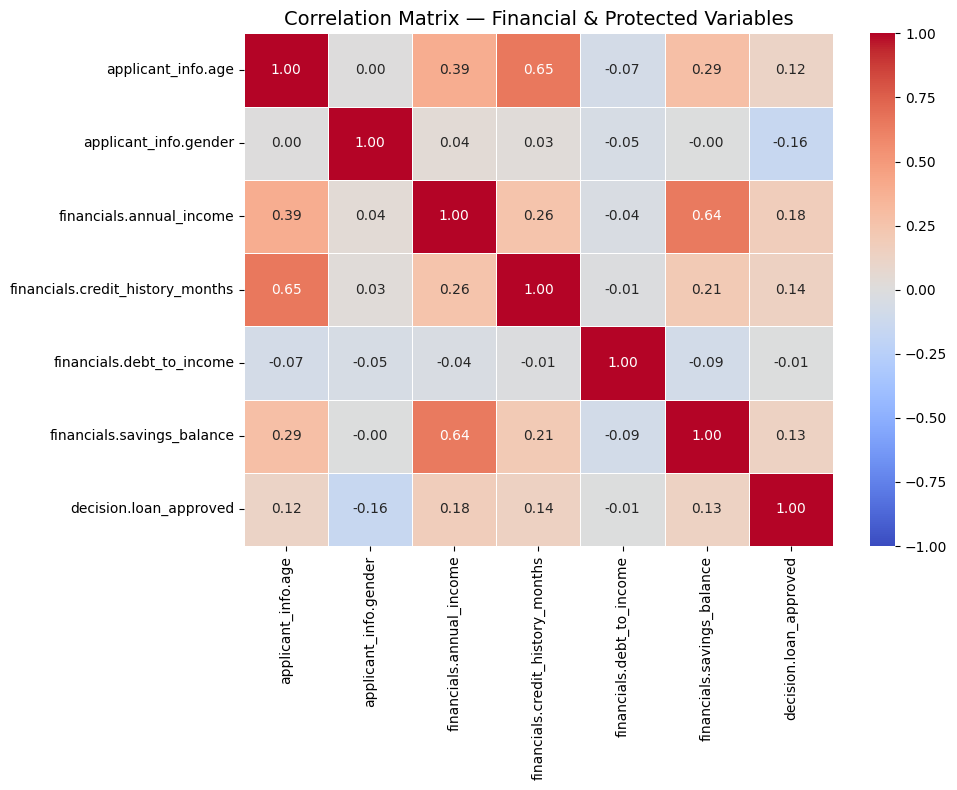

In [215]:
# Correlation Matrix
financial_vars = [
    'applicant_info.age',
    'applicant_info.gender',
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'decision.loan_approved'
]

# Encode gender for correlation
df_corr = df[financial_vars].copy()
df_corr['applicant_info.gender'] = df_corr['applicant_info.gender'].map({'Male': 0, 'Female': 1})

# Compute correlation
corr_matrix = df_corr.corr()

# Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title("Correlation Matrix — Financial & Protected Variables", fontsize=14)
plt.tight_layout()
plt.show()

The correlation matrix reveals two key findings: 

-  `credit_history_months` is strongly correlated with age (r = 0.65), confirming it as a proxy variable that structurally penalises younger applicants. 

- Gender, however, shows virtually no correlation with any financial variable (r ≈ 0.00). Despite this, gender returns a direct correlation of -0.16 with loan approval. 

These findings further corroborate that the gender disparity is not 
financially driven. Combined with the AIR analysis, Chi-Square Test, 
and logistic regression, the evidence consistently points to direct 
gender-based discrimination in the loan approval process.

The analysis now proceeds to intersectional analysis, in order to assess whether applicants belonging to multiple protected groups (young and female) experience compounded disparities in loan approval outcomes.

### 03.B Proxy Variables with Gender

In [218]:
# Proxy for gender 

df_gender = df[['applicant_info.gender',
                'financials.annual_income',
                'financials.savings_balance',
                'financials.debt_to_income']].dropna()

print("\nPROXY ANALYSIS — GENDER")

male   = df[df['applicant_info.gender'] == 'Male']
female = df[df['applicant_info.gender'] == 'Female']

for var in ['financials.annual_income', 
            'financials.savings_balance', 
            'financials.debt_to_income']:
    
    t, p = ttest_ind(male[var].dropna(), female[var].dropna())
    diff = male[var].mean() - female[var].mean()
    flag = "- Significant difference" if p < 0.05 else "- No significant difference"
    print(f"\n{var}:")
    print(f"  Male mean:   {male[var].mean():,.2f}")
    print(f"  Female mean: {female[var].mean():,.2f}")
    print(f"  Difference:  {diff:,.2f} | p = {p:.4f} {flag}")


PROXY ANALYSIS — GENDER

financials.annual_income:
  Male mean:   81,295.55
  Female mean: 83,770.65
  Difference:  -2,475.10 | p = 0.3264 - No significant difference

financials.savings_balance:
  Male mean:   29,659.85
  Female mean: 29,552.26
  Difference:  107.58 | p = 0.9428 - No significant difference

financials.debt_to_income:
  Male mean:   0.25
  Female mean: 0.24
  Difference:  0.01 | p = 0.2956 - No significant difference


The proxy analysis finds no statistically significant differences in financial variables across gender groups. Annual income (p = 0.326), savings balance (p = 0.943), and debt-to-income ratio (p = 0.296) are all comparable between male and female applicants. This confirms that no financial proxy is driving the gender disparity. 

Combined with the AIR, Chi-Square, and regression findings, the evidence points unambiguously to direct gender-based discrimination in the loan approval process.


### 03.B Proxy Variables with Age

In [223]:
## Proxy for Age

df_age = df[['applicant_info.age',
             'financials.credit_history_months',
             'financials.savings_balance']].dropna()


print("\nPROXY ANALYSIS — AGE")

corr, p = pearsonr(df_age['applicant_info.age'], 
                   df_age['financials.credit_history_months'])
print(f"\nAge vs Credit History Months: r = {corr:.3f}, p = {p:.4f}")
print("- Confirmed proxy" if p < 0.05 and corr > 0.3 else "- Not a significant proxy")

corr2, p2 = pearsonr(df_age['applicant_info.age'], 
                     df_age['financials.savings_balance'])
print(f"\nAge vs Savings Balance:       r = {corr2:.3f}, p = {p2:.4f}")
print("- Confirmed proxy" if p2 < 0.05 and corr2 > 0.3 else "- Not a significant proxy")



PROXY ANALYSIS — AGE

Age vs Credit History Months: r = 0.651, p = 0.0000
- Confirmed proxy

Age vs Savings Balance:       r = 0.287, p = 0.0000
- Not a significant proxy


The proxy analysis identifies `credit_history_months` as a confirmed proxy  for age (r = 0.651, p < 0.001). Using credit history as an approval criterion indirectly penalises younger applicants, as it accumulates  naturally over time. `savings_balance` shows a weak and non-meaningful  correlation (r = 0.287). 

The adverse impact observed in the 18-30 age  group is therefore at least partially driven by indirect discrimination  through the use of credit history length as an approval criterion.

---
## 04. Interaction effects between attributes
---

The intersectional analysis examines whether belonging to multiple protected groups simultaneously produces compounded disparities beyond  what each attribute causes individually. 
Prior analyses identified female applicants and the 18-30 age group as the two disadvantaged groups. Male applicants and the 60+ age group were identified as the respective reference groups. The intersectional analysis therefore focuses on four combinations: 
- Female & 18-30
- Male & 18-30
- female & 60+ 
- Male & 60+ 

This design isolates the pure effect of each attribute individually, while testing whether their combination produces a compounded disadvantage exceeding the sum of individual effects.

---
## 0.5 Conclusion
---